In [117]:

%load_ext autoreload
%autoreload 2
from mGST.low_level_jit import cost_function_jax_mps, objf
from mGST.utility_functions_comparisons import create_4q_gst_config, get_compressed_perturbed_rep_from_mgst, target_kraus_tensor_from_configuration, kraus_tensor_to_mgst, get_compressed_perturbed_kraus_from_superop, factorize_psd_truncated, povm_psd_to_mgst, state_psd_to_mgst, get_mgst_tensors_from_psd_representation,get_compressed_rep_from_mgst_output

from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

from mGST.reporting.reporting import gauge_opt, generate_basis_labels
from mGST.compatibility import arrays_to_pygsti_model, std2pp
from mGST.reporting.figure_gen import generate_gate_err_pdf

import jax.numpy as jnp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Loading data

In [ ]:
tensors_from_config = jnp.load("data/gst_tensors_4q_10000seq_500shots.npz", allow_pickle=True) # allow pickle because indices list has different lengths
tensors_from_config.keys()

KeysView(NpzFile 'data/gst_tensors_4q_10000seq_500shots.npz' with keys: kraus_tensor_mgst, povm_mgst, state_mgst, prob_matrix, indices_list)

In [5]:
kraus_tensor_mgst = tensors_from_config["kraus_tensor_mgst"]
povm_mgst = tensors_from_config["povm_mgst"]
state_mgst = tensors_from_config["state_mgst"]
prob_matrix = tensors_from_config["prob_matrix"]
indices_list = tensors_from_config["indices_list"]

# Initial perturbed tensors

In [6]:
# Kraus is already perturbed
kraus_tensor_init_jax = jnp.array(kraus_tensor_mgst)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst, state_mgst)

init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

INFO:2026-03-01 20:16:03,062:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-03-01 20:16:03,062 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-03-01 20:16:03,068:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 704 the new count changed to: 5
at iteration 1317 the new count changed to: 6
at iteration 1930 the new count changed to: 7
at iteration 2544 the new count changed to: 8
at iteration 3158 the new count changed to: 9
at iteration 3772 the new count changed to: 10
at iteration 4386 the new count changed to: 11
at iteration 5000 the new count changed to: 12
at iteration 5555 the new count changed to: 13
at iteration 6110 the new count changed to: 14
at iteration 6665 the new count changed to: 15
at iteration 7220 the new count changed to: 16
at iteration 7776 the new count changed to: 17
at iteration 8332 the new count changed to: 18
at iteration 8888 the new count changed to: 19
at iteration 9444 the new count changed to: 20
Initial cost value: 0.0008497723475486373


In [7]:
# shape of the tensors right now
[op.shape for op in init_operators_jax.values()]

[(9, 1, 16, 16), (16, 16, 16), (16, 16)]

## Changing ranks

In [13]:
num_gate_sequences = 10000
shots = 500
Q4_GST_config = create_4q_gst_config(kraus_rank=1, num_gate_sequences=num_gate_sequences, shots=shots) # we only need this to create the target kraus so in reality it doesn't matter.
kraus_tensor_target = target_kraus_tensor_from_configuration(configuration=Q4_GST_config)
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_tensor_init_rank_4 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=4, seed=42)["kraus_tensor"]
kraus_tensor_init_rank_4.shape

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/utility_functions_comparisons.py:184: UserWarning: No backend specified. Using 'iqmfakeapollo' as default backend.
  warnings.warn("No backend specified. Using 'iqmfakeapollo' as default backend.")


(9, 4, 16, 16)

In [14]:
cost_function_jax_mps(kraus_tensor_init_rank_4, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 704 the new count changed to: 5
at iteration 1317 the new count changed to: 6
at iteration 1930 the new count changed to: 7
at iteration 2544 the new count changed to: 8
at iteration 3158 the new count changed to: 9
at iteration 3772 the new count changed to: 10
at iteration 4386 the new count changed to: 11
at iteration 5000 the new count changed to: 12
at iteration 5555 the new count changed to: 13
at iteration 6110 the new count changed to: 14
at iteration 6665 the new count changed to: 15
at iteration 7220 the new count changed to: 16
at iteration 7776 the new count changed to: 17
at iteration 8332 the new count changed to: 18
at iteration 8888 the new count changed to: 19
at iteration 9444 the new count changed to: 20


Array(0.00061944, dtype=float64)

In [15]:
initial_cost_value

Array(0.00084977, dtype=float64)

In [25]:
# state and povm ranks
state_rank, povm_rank = 4, 4

In [ ]:
# factorize the full state and povm perturbed
num_povm, rank_povm, dim = povm_psd_init_jax.shape
povm_mgst_perturbed = povm_psd_to_mgst(povm_psd_init_jax).reshape(num_povm, dim, dim)
povm_psd_init_compressed = factorize_psd_truncated(povm_mgst_perturbed, max_rank=povm_rank).conj().transpose(0, 2, 1) # we need to transpose because the factorization gives us something of shape (num_povm, dim, rank) but we need (num_povm, rank, dim) to do the einsum and get back the povm_mgst_perturbed    
jnp.allclose(povm_mgst_perturbed, jnp.einsum("ijl,ijk->ilk", povm_psd_init_compressed.conj(), povm_psd_init_compressed))

Array(True, dtype=bool)

In [31]:
# do the same for the state
state_mgst_perturbed = state_psd_to_mgst(state_psd_init_jax).reshape(dim, dim)
state_psd_init_compressed = factorize_psd_truncated(state_mgst_perturbed, max_rank=state_rank)
jnp.allclose(state_mgst_perturbed, state_psd_init_compressed @ state_psd_init_compressed.conj().T)

Array(True, dtype=bool)

In [34]:
# new init tensor
init_operators_compressed = {
    "kraus_tensor_init": kraus_tensor_init_rank_4,
    "povm_psd_init": povm_psd_init_compressed,
    "state_psd_init": state_psd_init_compressed,
}
# shape of the new tensors
print([op.shape for op in init_operators_compressed.values()])
# new cost function
cost_fn_compressed = cost_function_jax_mps(*init_operators_compressed.values(), **cost_fn_kwargs)

[(9, 4, 16, 16), (16, 4, 16), (16, 4)]
at iteration 0 the new count changed to: 21
at iteration 1 the new count changed to: 22
at iteration 10 the new count changed to: 23
at iteration 91 the new count changed to: 24
at iteration 704 the new count changed to: 25
at iteration 1317 the new count changed to: 26
at iteration 1930 the new count changed to: 27
at iteration 2544 the new count changed to: 28
at iteration 3158 the new count changed to: 29
at iteration 3772 the new count changed to: 30
at iteration 4386 the new count changed to: 31
at iteration 5000 the new count changed to: 32
at iteration 5555 the new count changed to: 33
at iteration 6110 the new count changed to: 34
at iteration 6665 the new count changed to: 35
at iteration 7220 the new count changed to: 36
at iteration 7776 the new count changed to: 37
at iteration 8332 the new count changed to: 38
at iteration 8888 the new count changed to: 39
at iteration 9444 the new count changed to: 40


In [35]:
cost_fn_compressed

Array(0.00061944, dtype=float64)

In [64]:
len(state_psd_init_jax.nonzero()[0]), len(state_psd_init_compressed.nonzero()[0]), len(state_mgst.nonzero()[0])

(16, 4, 1)

In [65]:
len(povm_psd_init_jax.nonzero()[0]), len(povm_psd_init_compressed.nonzero()[0]), len(povm_mgst.nonzero()[0])

(256, 64, 16)

# Time estimation

In [66]:
timing_compressed = %timeit -o cost_function_jax_mps(*init_operators_compressed.values(), **cost_fn_kwargs)

2.07 s ± 2.52 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Opimization

In [70]:
relative_precision = 1e-5
num_shots = 500
noise_threshold = estimate_noise_floor_threshold(prob_matrix, num_shots=num_shots, multiplier=1.0)

print("Noise threshold: ", noise_threshold)

num_iterations_outer = 3 # max 3 (hopefully less)
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

Noise threshold:  0.0001016521870999998


{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=2, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=2, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=2, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

In [73]:
# After 41 iterations (10 povm, 10 kraus, 2 state, 10 povm, 9 kraus)
# 249 mins 45 seconds
# finished kraus in 271 mins

In [ ]:
optimized_operators, cost_fn_history= run_riemannian_optimization(
    **init_operators_compressed,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=None, # do not stop if we go below this.
    relative_precision=relative_precision,
    verbose=True,
) #. 464m 53.4s

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-2]: TrustRegionOptions
povm: Schedule:
  [0-2]: TrustRegionOptions
state: Schedule:
  [0-2]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 6.194426e-04. |r∇f(x)|: 3.200236e-04. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 5.936455e-04. |r∇f(x)|: 1.984850e-04. Radius: 2.00e-01
TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 5.744546e-04. |r∇f(x)|: 3.712849e-05. Radius: 4.00e-01
TCG finished after: 9/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.744546e-04. |r∇f(x)|: 3.712849e-05. Radius: 1.00e-01
TCG 

In [74]:
# save cost function and optimized operators
jnp.savez(
    "optimization_results_4q_10000seq_500shots_rank_4.npz",
    kraus_tensor=optimized_operators["kraus"],
    povm_psd=optimized_operators["povm"],
    state_psd=optimized_operators["state"],
    cost_fn_history=cost_fn_history,
)

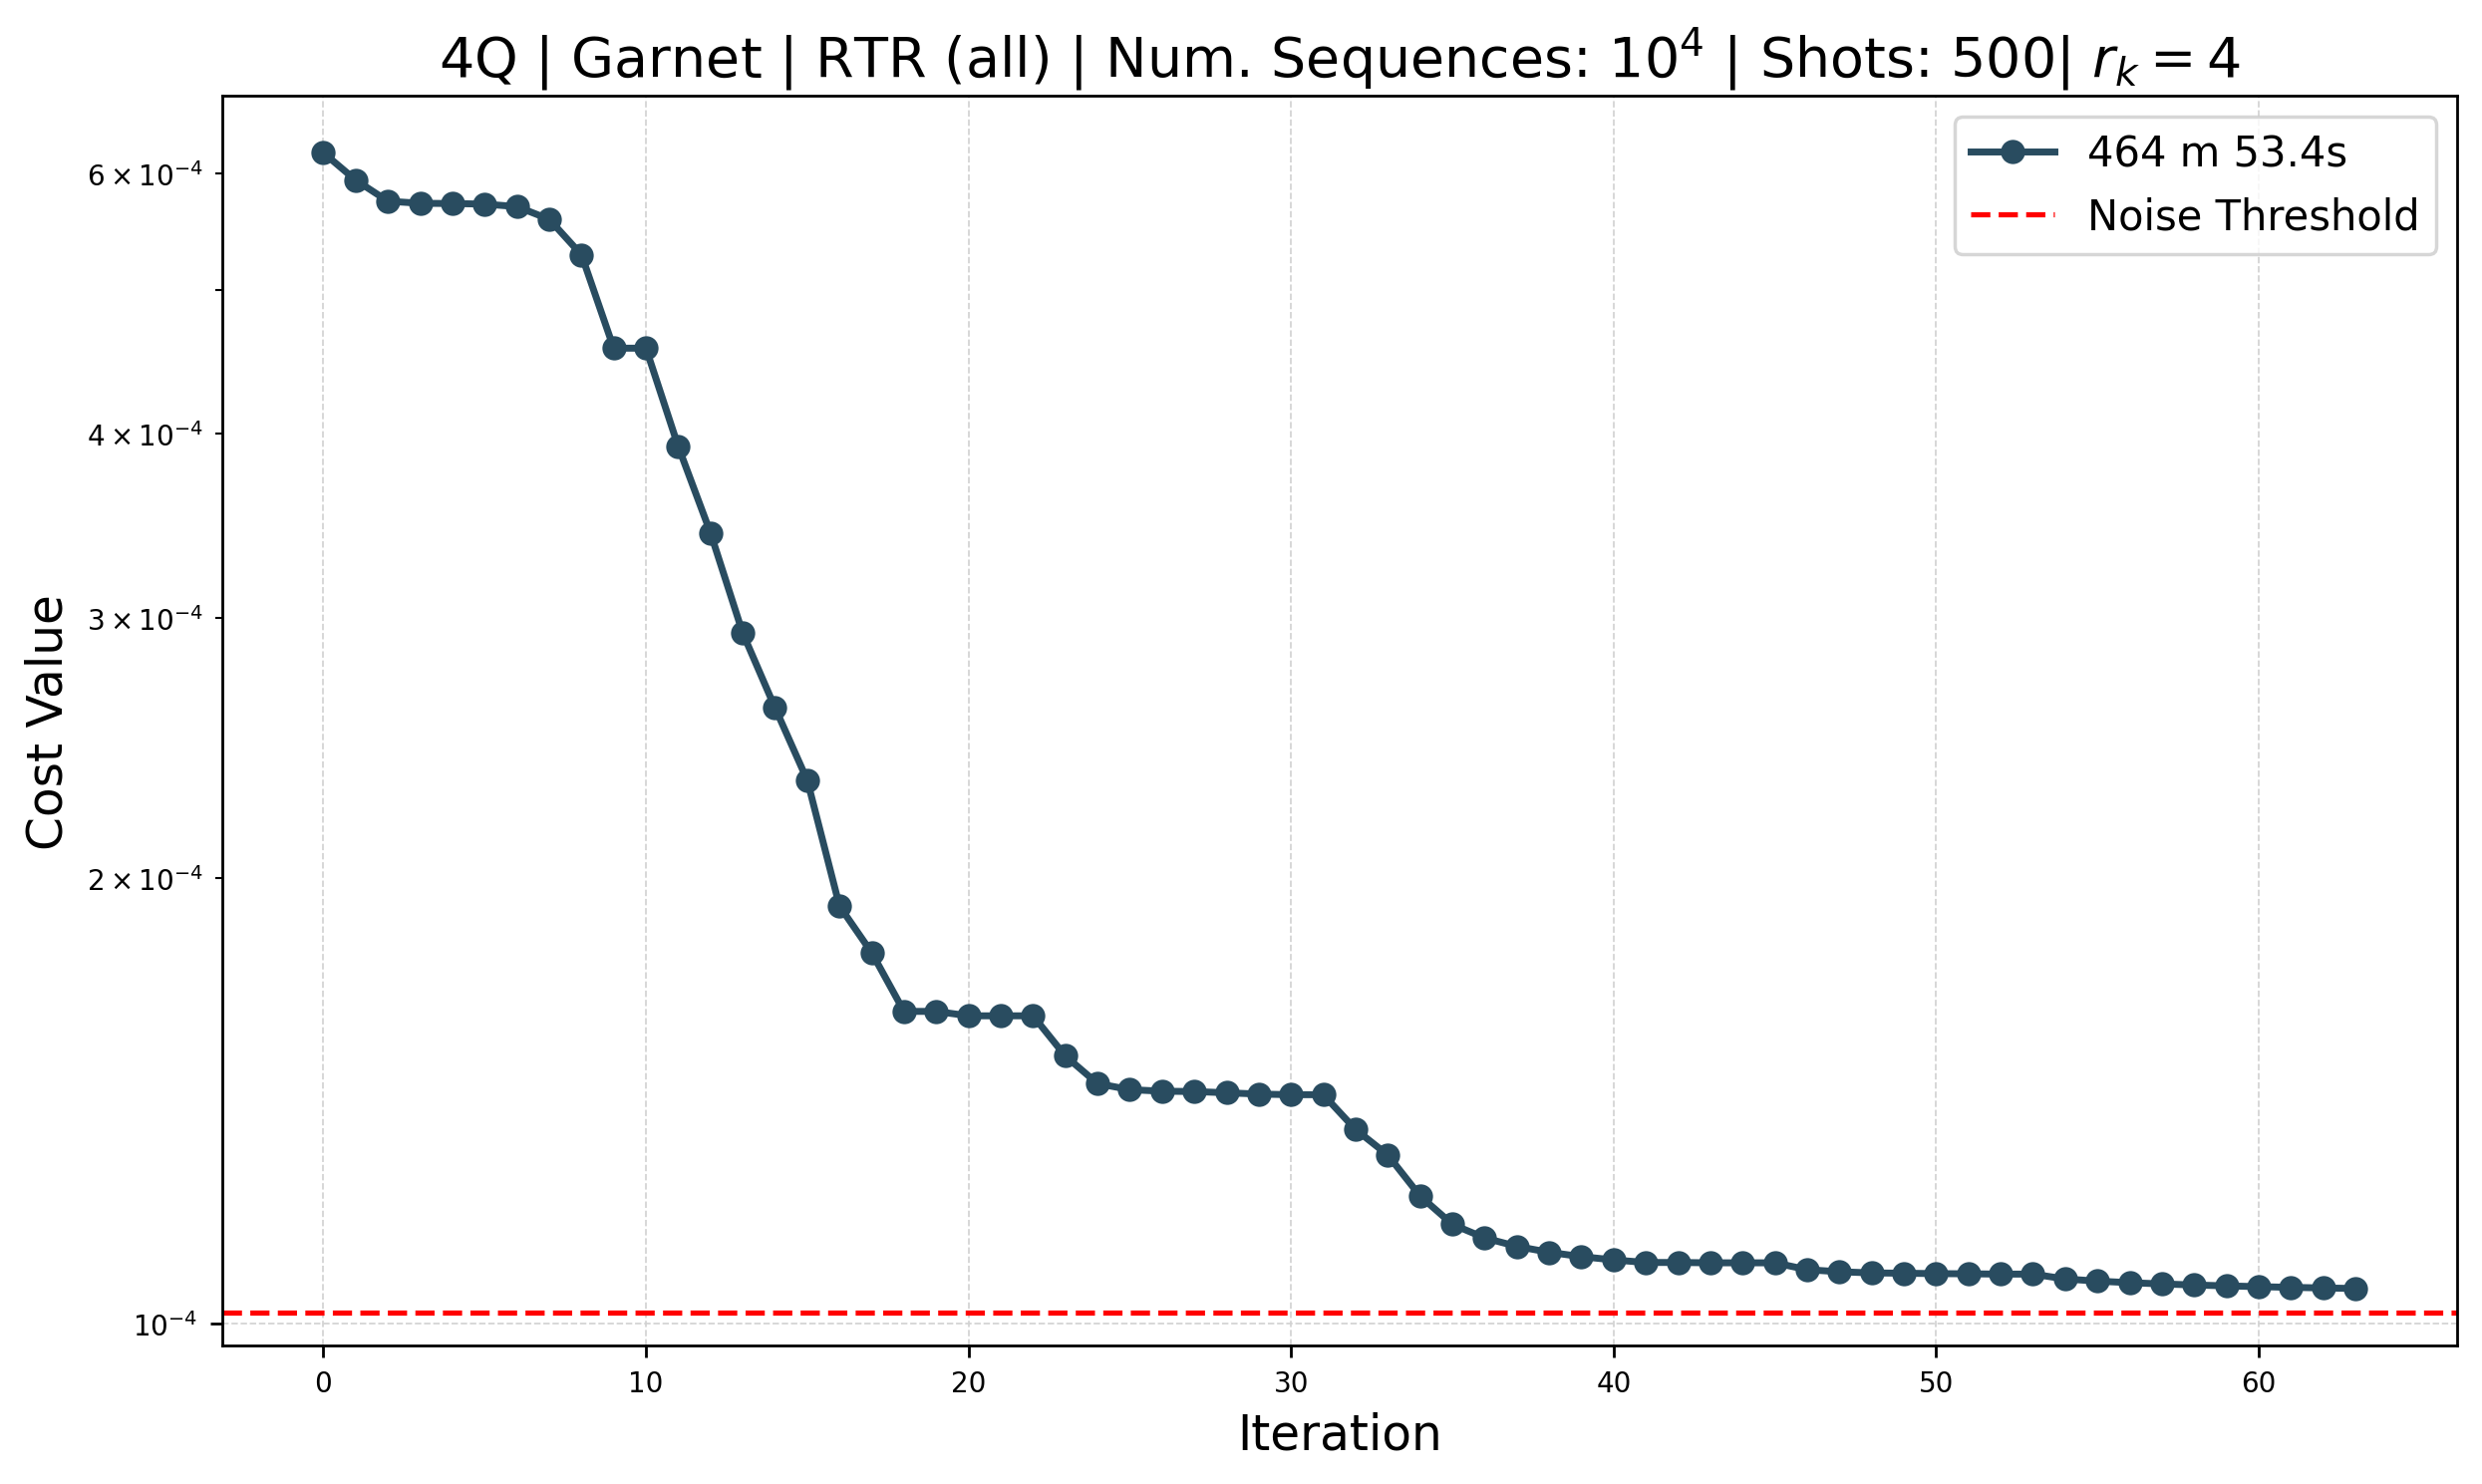

In [ ]:
plot_cost_function(
    cost_array=[cost_fn_history],
    labels=[r"464 m 53.4s"],
    comparison_yline=noise_threshold,
    comparison_label="Noise Threshold",
    title="4Q | Garnet | RTR (all) | Num. Sequences: $10^4$ | Shots: 500| $r_k = 4, r_A = $"
)

# Gauge optimization

In [85]:
gauge_weights = {'G0': 1,
 'G1': 1,
 'G2': 1,
 'G3': 1,
 'G4': 1,
 'G5': 1,
 'G6': 1,
 'G7': 1,
 'G8': 1,
 'spam': 0.1}

kraus_tensor_opt = optimized_operators["kraus"]
povm_psd_opt = optimized_operators["povm"]
state_psd_opt = optimized_operators["state"]

In [82]:
target_ops = {
    "X": kraus_superop_target,
    "E": povm_mgst,
    "rho": state_mgst
}

target_model_pygsti = arrays_to_pygsti_model(**target_ops, basis="std")

[op.shape for op in target_ops.values()]

[(9, 256, 256), (16, 256), (256,)]

In [86]:
optimized_ops_mgst = get_mgst_tensors_from_psd_representation(kraus_tensor_opt, povm_psd_opt, state_psd_opt)
[(key, op.shape) for key, op in optimized_ops_mgst.items()]

[('kraus', (9, 256, 256)), ('povm', (16, 256)), ('state', (256,))]

In [87]:
kraus_mgst_gauge_opt, povm_mgst_gauge_opt, state_mgst_gauge_opt = gauge_opt(
    X=optimized_ops_mgst["kraus"],
    E=optimized_ops_mgst["povm"],
    rho=optimized_ops_mgst["state"],
    target_mdl=target_model_pygsti,
    weights=gauge_weights)

In [89]:
# what are their shapes?
kraus_mgst_gauge_opt.shape, povm_mgst_gauge_opt.shape, state_mgst_gauge_opt.shape

((9, 256, 256), (16, 256), (256,))

### Note:
it took `10 mins 31.5 s` to optimize the Gauge for this Gate Set!

## Save gauge optimized operators (and target for convenience)

In [119]:
jnp.savez(
    "ops_gauge_optimized_mgst_4q_rank_4_all.npz",
    kraus=kraus_mgst_gauge_opt,
    povm=povm_mgst_gauge_opt,
    state=state_mgst_gauge_opt,
)

jnp.savez(
    "ops_target_mgst_4q_rank_4_all.npz",
    kraus=kraus_superop_target,
    povm=povm_mgst,
    state=state_mgst,
)

# Basic checks on the gauge optimized operators

In [91]:
rank = 4

In [93]:
kraus_tensor_gauge_opt, povm_psd_gauge_opt, state_psd_gauge_opt = get_compressed_rep_from_mgst_output(
    kraus_mgst=kraus_mgst_gauge_opt,
    povm_mgst=povm_mgst_gauge_opt,
    state_mgst=state_mgst_gauge_opt,
    kraus_rank=rank, state_rank=rank, povm_rank=rank)

gauge_opt_psd_operators = {
    "kraus_tensor": kraus_tensor_gauge_opt,
    "povm_psd": povm_psd_gauge_opt,
    "state_psd": state_psd_gauge_opt,
}

[op.shape for op in gauge_opt_psd_operators.values()]

[(9, 4, 16, 16), (16, 4, 16), (16, 4)]

In [94]:
# Checking the cost function is the same as for the optimized operators without gauge optimization
cost_value_opt = cost_function_jax_mps(*optimized_operators.values(), **cost_fn_kwargs)
cost_value_gauge_opt = cost_function_jax_mps(**gauge_opt_psd_operators, **cost_fn_kwargs)

print("Are the costs the same?", jnp.allclose(cost_value_gauge_opt, cost_value_opt))
print("cost:", cost_value_gauge_opt, cost_value_opt)

Are the costs the same? True
cost: 0.00010560322854027844 0.00010560322854027894


# Attempt at creating full Pauli transfer matrix for CZ-CZ

In [155]:
gate_labels = {0: 'Rx(pi/2)',
 1: 'Rx(pi/2)',
 2: 'Rx(pi/2)',
 3: 'Rx(pi/2)',
 4: 'Ry(pi/2)',
 5: 'Ry(pi/2)',
 6: 'Ry(pi/2)',
 7: 'Ry(pi/2)',
 8: 'CZ-CZ'}

# dim = 2**4
pauli_labels = generate_basis_labels(pdim=dim, basis="Pauli")
len(pauli_labels)

ops_gauge_opt = {
    "kraus": kraus_mgst_gauge_opt,
    "povm": povm_mgst_gauge_opt,
    "state": state_mgst_gauge_opt,
}

In [113]:
kraus_superop_target_pauli, *_ = std2pp(*target_ops.values())
# Convert to pauli basis
kraus_superop_gauge_opt_pauli, *_ = std2pp(*ops_gauge_opt.values())

# Looking only at the last gate (CZ-CZ)
kraus_superop_gauge_pauli_cz_cz = kraus_superop_gauge_opt_pauli[-1:] # do this to keep the tensor rank 3
kraus_superop_target_pauli_cz_cz = kraus_superop_target_pauli[-1:]
gate_labels_cz_cz = [gate_labels[8]]

kraus_superop_gauge_pauli_cz_cz.shape, kraus_superop_target_pauli_cz_cz.shape

((1, 256, 256), (1, 256, 256))

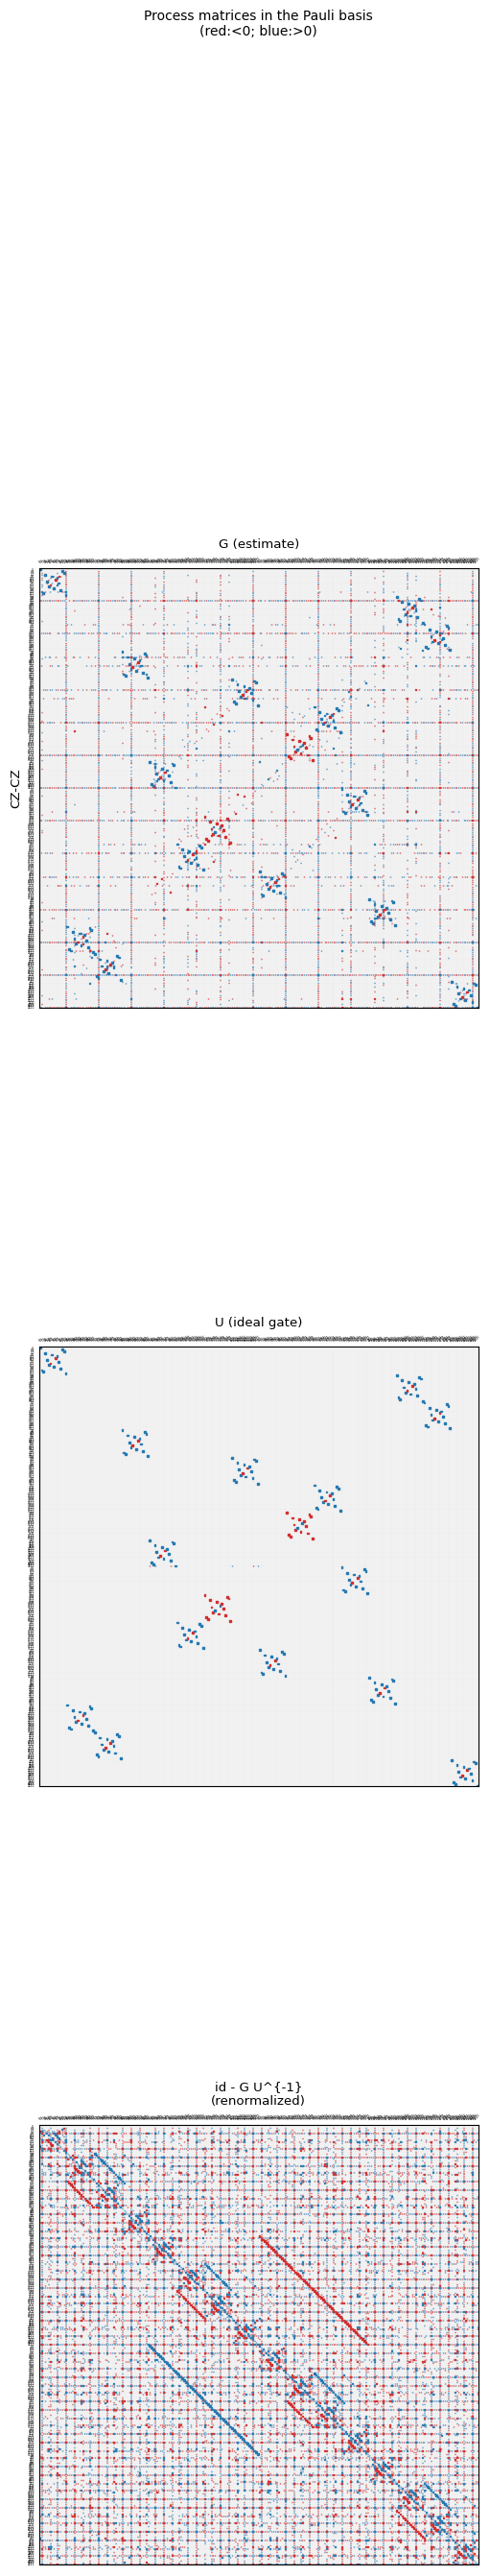

In [118]:
figures_cz_cz = generate_gate_err_pdf(
        "cz_cz_new.pdf",
        gates1=kraus_superop_gauge_pauli_cz_cz,
        gates2=kraus_superop_target_pauli_cz_cz,
        basis_labels=pauli_labels,
        gate_labels=gate_labels_cz_cz,
        return_fig=False,
        dpi=300
    )

In [120]:
figures_cz_cz_v2 = generate_gate_err_pdf(
        "cz_cz_new.pdf",
        gates1=kraus_superop_gauge_pauli_cz_cz,
        gates2=kraus_superop_target_pauli_cz_cz,
        basis_labels=pauli_labels,
        gate_labels=gate_labels_cz_cz,
        save_fig=True,
        dpi=300
    )

In [125]:
figures_cz_cz_v2[-1].savefig("cz_cz_white_bg.pdf", dpi=300, transparent=False, bbox_inches="tight")

In [175]:
# Error matrix:
Id = jnp.eye(dim**2)
cz_cz_target = kraus_superop_target_pauli_cz_cz[0]
cz_cz_real = kraus_superop_gauge_pauli_cz_cz[0]
cz_cz_target_inv = jnp.linalg.inv(cz_cz_target)
relative_ptm = cz_cz_real @ cz_cz_target_inv
error_ptm = Id - relative_ptm

# Making sense of our error matrices

In [180]:
jnp.linalg.norm(Id)

Array(16., dtype=float64)

In [197]:
matrix = error_ptm
diag_error = jnp.diag(jnp.diag(matrix))
non_pauli_error_ptm = matrix - diag_error

total_norm = jnp.linalg.norm(matrix, ord="fro")
non_pauli_error_norm = jnp.linalg.norm(non_pauli_error_ptm, ord="fro")
pauli_error_norm = jnp.linalg.norm(diag_error, ord="fro")

non_pauli_fraction = (non_pauli_error_norm / total_norm) **2
pauli_fraction = (pauli_error_norm / total_norm) ** 2
total_relative_error = total_norm / dim # norm of identity

print(f"||E||_F = {total_norm:.6g}")
print(f"||diag(E)||_F = {pauli_error_norm:.6g}")
print(f"||offdiag(E)||_F = {non_pauli_error_norm:.6g}")
print(f"non-Pauli fraction = {non_pauli_fraction:.3%}")
print(f"Pauli fraction = {pauli_fraction:.3%}")
print(f"Total relative error = {total_relative_error:.3%}")
print(f"Σ =  {non_pauli_fraction + pauli_fraction}")

||E||_F = 1.01857
||diag(E)||_F = 0.219184
||offdiag(E)||_F = 0.994704
non-Pauli fraction = 95.369%
Pauli fraction = 4.631%
Total relative error = 6.366%
Σ =  1.0


In [199]:
from mGST.reporting.reporting import unitarities

unitarities_cz_cz = unitarities(kraus_superop_gauge_pauli_cz_cz)
unitarities_cz_cz

array([0.97695872])

In [ ]:
# Just checking they are orthongonal
# naturally they are, since the diagonal terms get multiplied and then the trace only looks at those (zero)
jnp.trace(diag_error @ non_pauli_error_ptm)

Array(0.+0.j, dtype=complex128)

In [ ]:
# trace(I @ I) = trace (I) = dim
jnp.linalg.norm(Id, ord="fro")**2

Array(256., dtype=float64)

In [165]:
# is the reconstructed pauli transfer matrix trace preserving
cz_cz_real[0, 0], jnp.sum(cz_cz_real[0, :])

((1.0000000000000002+0j), Array(1.+0.j, dtype=complex128))

In [164]:
# first element of the "error" should be one
print(relative_ptm[0, 0])

# is it trace preserving? (sum of first row should be 1)
# think about this as contracting the identity on the left, i.e. the adjoint chanel is unital.
print(jnp.sum(relative_ptm[0, :]))
# is it unital? (sum of first column should be 1)
print(jnp.sum(relative_ptm[:, 0]))

(1.0000000000000002+0j)
(1.0000000000000007+0j)
(1.0013009041243024+0j)


# Tests from ChatGPT

In [ ]:
import itertools
# --- build Pauli labels and weights for n qubits ---
paulis = ['I','X','Y','Z']
def get_pauli_labels(n):
    labels = []
    for tup in itertools.product(paulis, repeat=n):
        labels.append(''.join(tup))
    return labels

num_qubits = 4
labels = get_pauli_labels(num_qubits)

In [ ]:
def pauli_weight(label):
    return sum(1 for c in label if c != 'I')

# --- group indices ---
A_idx = [i for i,l in enumerate(labels) if all(l[q]=='I' for q in (2,3)) and pauli_weight(l)>0]  # acts only on q0,q1
B_idx = [i for i,l in enumerate(labels) if all(l[q]=='I' for q in (0,1)) and pauli_weight(l)>0]  # acts only on q2,q3
X_idx = [i for i,l in enumerate(labels) if (any(l[q] != 'I' for q in (0,1)) and any(l[q] != 'I' for q in (2,3)))]

A_idx = jnp.array(A_idx)
B_idx = jnp.array(B_idx)
X_idx = jnp.array(X_idx)

# include identity if you want (here we exclude the all-identity from groups)
id_idx = labels.index('IIII')

# --- block norms (Frobenius) ---
def block_norm(mat, rows, cols):
    return jnp.linalg.norm(mat[jnp.ix_(rows, cols)], ord='fro')

norm_AA = block_norm(relative_ptm, A_idx, A_idx)
norm_BA = block_norm(relative_ptm, B_idx, A_idx)
norm_XA = block_norm(relative_ptm, X_idx, A_idx)

print("||M_AA||_F = ", norm_AA)
print("||M_BA||_F = ", norm_BA, "   ratio =", norm_BA / (norm_AA+1e-12))
print("||M_XA||_F = ", norm_XA, "   ratio =", norm_XA / (norm_AA+1e-12))

# --- per-column leakage into mixed (X) for columns in A ---
leakage_per_col = {j: jnp.sum(jnp.abs(relative_ptm[X_idx, j])) for j in A_idx}
# Show top offenders
num_cols_to_show = 16
top = sorted(leakage_per_col.items(), key=lambda kv: -kv[1])[:num_cols_to_show]
print("Top leakage columns (index, label, leakage):")
for j,l in top:
    print(j, labels[j], l)

||M_AA||_F =  3.843127882805299
||M_BA||_F =  0.009163968623536129    ratio = 0.0023845078547957365
||M_XA||_F =  0.07170749049412235    ratio = 0.01865862721220733
Top leakage columns (index, label, leakage):
32 IYII 0.2177770064481067
192 ZIII 0.20887547446214458
48 IZII 0.20833917924911452
128 YIII 0.20794851526045738
112 XZII 0.20733895424841453
16 IXII 0.20709171389733644
80 XXII 0.20299450189089424
160 YYII 0.19996285854480744
96 XYII 0.19963414753595204
240 ZZII 0.19868976191563337
64 XIII 0.19735250524444203
208 ZXII 0.19731632690416379
224 ZYII 0.19478803295031588
176 YZII 0.19437243662546871
144 YXII 0.18893851634574846


In [138]:

# compute leakage L_j (you already have) and useful denominators
leakage = {j: jnp.sum(jnp.abs(relative_ptm[X_idx, j])) for j in A_idx}
col_abs_sum = {j: jnp.sum(jnp.abs(relative_ptm[:, j])) for j in A_idx}
col_A_sum = {j: jnp.sum(jnp.abs(relative_ptm[A_idx, j])) for j in A_idx}
diag = {j: jnp.abs(relative_ptm[j, j]) for j in A_idx}

# build a table of top offenders with fractions
top = sorted(leakage.items(), key=lambda kv: -kv[1])[:12]
print("idx, label, leakage, leakage/col_sum, leakage/col_A_sum, leakage/diag")
for j, L in top:
    print(j,
          labels[j],
          f"{L:.4f}",
          f"{(L/col_abs_sum[j]):.3f}",
          f"{(L/col_A_sum[j]):.3f}",
          f"{(L/(diag[j]+1e-12)):.3f}")

# Inspect which X-rows contribute most for the top column
j_top = top[0][0]   # index of top offender
row_vals = [(i, labels[i], relative_ptm[i, j_top]) for i in X_idx]
row_vals_sorted = sorted(row_vals, key=lambda x: -abs(x[2]))[:12]
print("\nTop mixed rows receiving amplitude for column", labels[j_top])
for i, lab, val in row_vals_sorted:
    print(i, lab, val)

idx, label, leakage, leakage/col_sum, leakage/col_A_sum, leakage/diag
32 IYII 0.2178 0.172 0.209 0.220
192 ZIII 0.2089 0.170 0.208 0.211
48 IZII 0.2083 0.168 0.203 0.209
128 YIII 0.2079 0.163 0.197 0.210
112 XZII 0.2073 0.162 0.195 0.209
16 IXII 0.2071 0.164 0.198 0.209
80 XXII 0.2030 0.157 0.186 0.205
160 YYII 0.2000 0.155 0.185 0.202
96 XYII 0.1996 0.154 0.184 0.202
240 ZZII 0.1987 0.163 0.196 0.200
64 XIII 0.1974 0.156 0.186 0.199
208 ZXII 0.1973 0.158 0.189 0.199

Top mixed rows receiving amplitude for column IYII
44 IYZI (-0.006201295115975551+0j)
35 IYIZ (0.004947986385370237+0j)
39 IYXZ (0.0035077930454719096+0j)
117 XZXX (0.00324781705825844+0j)
246 ZZXY (0.003073184297737064+0j)
213 ZXXX (0.0029636111339137183+0j)
43 IYYZ (-0.0029017333841262257+0j)
59 IZYZ (-0.002894505133078572+0j)
93 XXZX (-0.0028665797669585+0j)
55 IZXZ (-0.0028059975418409907+0j)
86 XXXY (0.0027711832409646367+0j)
154 YXYY (-0.0027087528405957927+0j)
